 2. LOADING DATASET & INITIAL INSPECTION 

--- First 5 Rows ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

--- Dataset Shape ---
Rows: 20640, Columns: 9

--- Column Names ---
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'price']

--- Data Types ---
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      floa

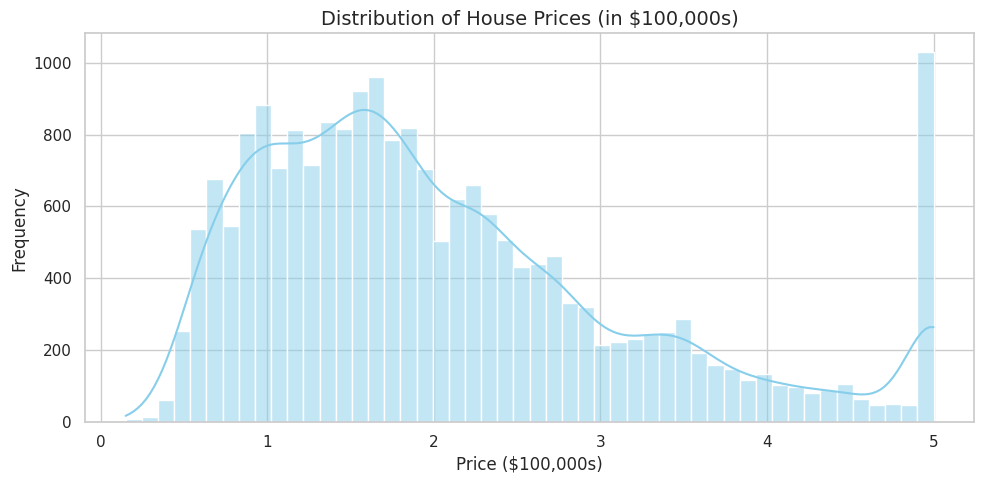

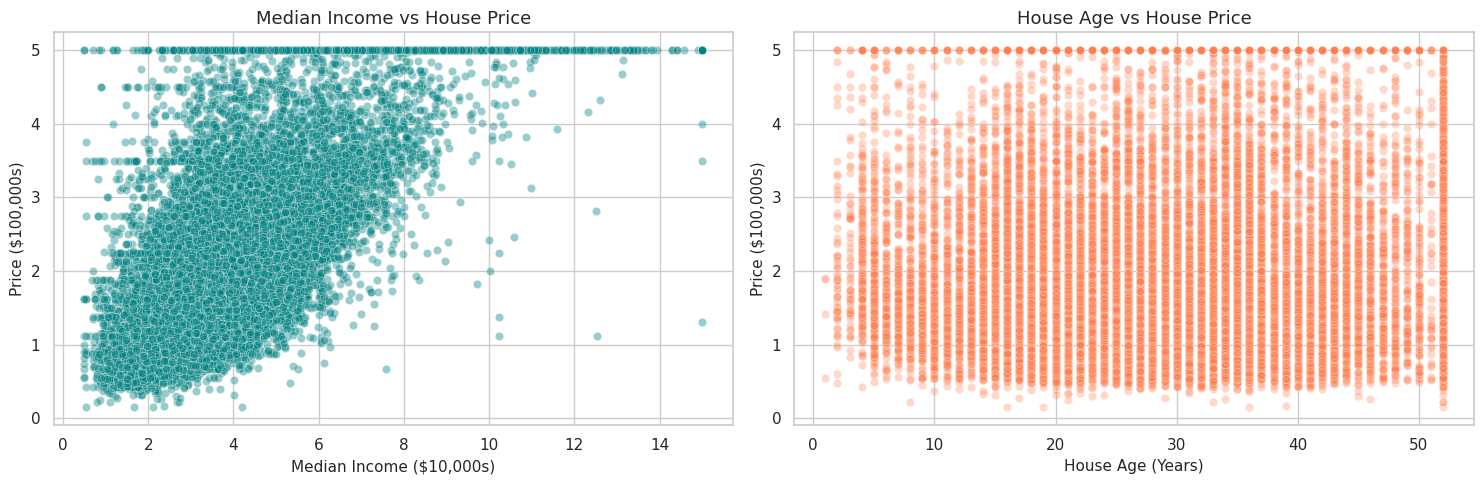

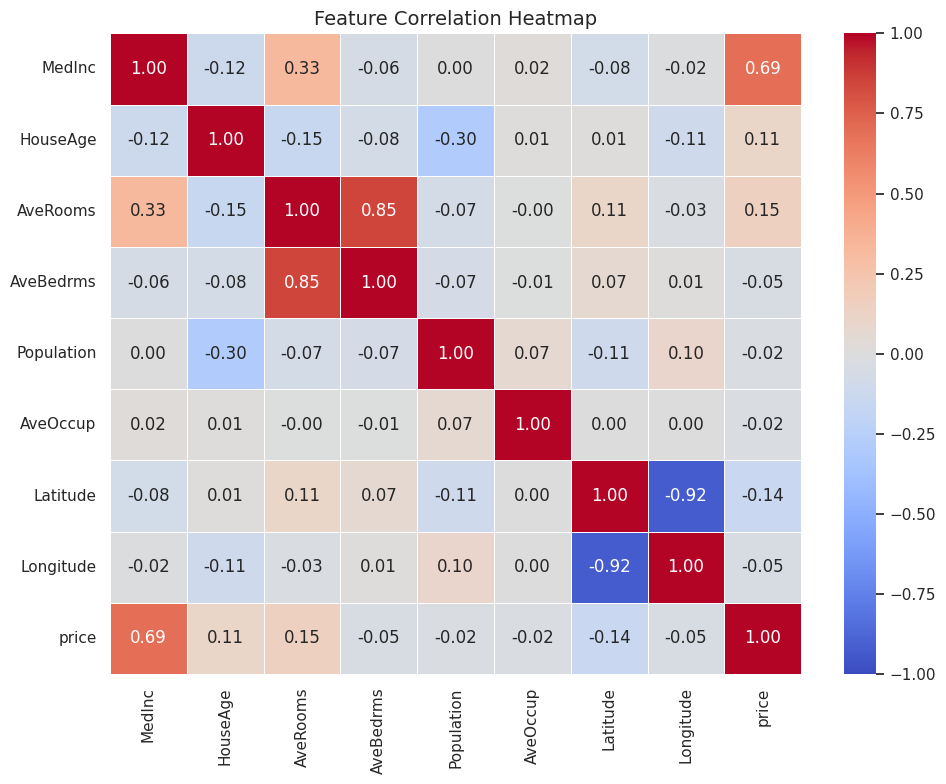


Feature Matrix (X) Shape: (20640, 8)
Target Vector (y) Shape: (20640,)

--- Train-Test Split Results ---
Training set size (X_train): 16512 samples
Testing set size (X_test):   4128 samples

 5. TRAINING MODELS 

Training Linear Regression Model...
Linear Regression Training Complete.

Training Random Forest Regressor...
Random Forest Training Complete.

 6. MODEL EVALUATION & COMPARISON 

--- Model Performance Comparison ---
            Model      MAE      MSE     RMSE  R2 Score
Linear Regression 0.533200 0.555892 0.745581  0.575788
    Random Forest 0.327543 0.255368 0.505340  0.805123


/tmp/ipykernel_3264/3829351339.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=comparison_df, x='Model', y='R2 Score', palette='viridis')
/tmp/ipykernel_3264/3829351339.py:223: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=comparison_df, x='Model', y='MAE', palette='magma')


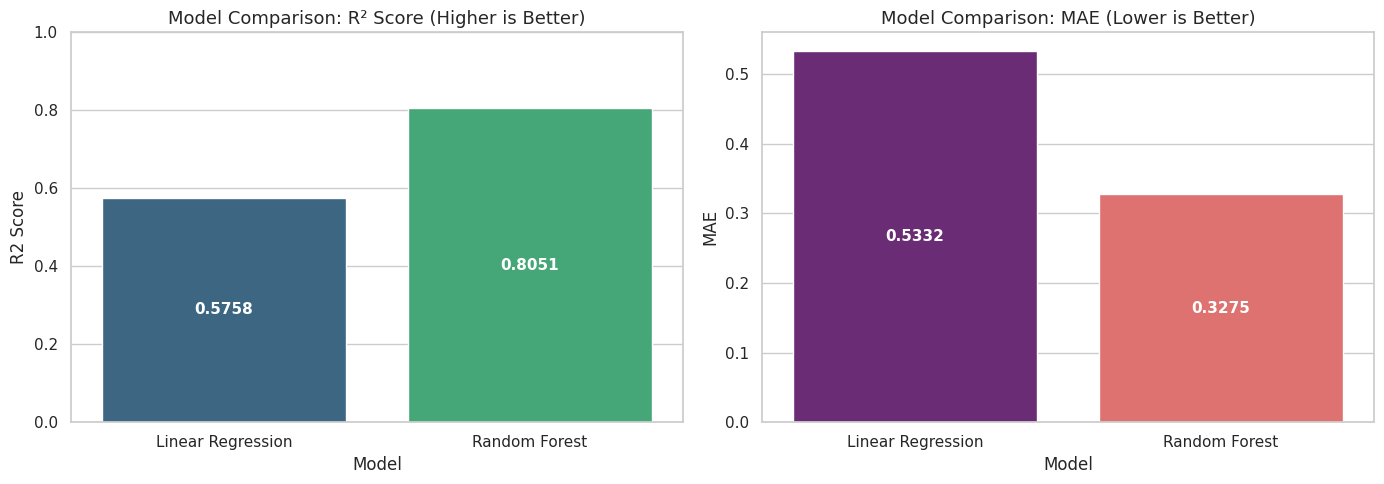


 BEST PERFORMING MODEL: RANDOM FOREST 
 Best R² Score: 0.8051


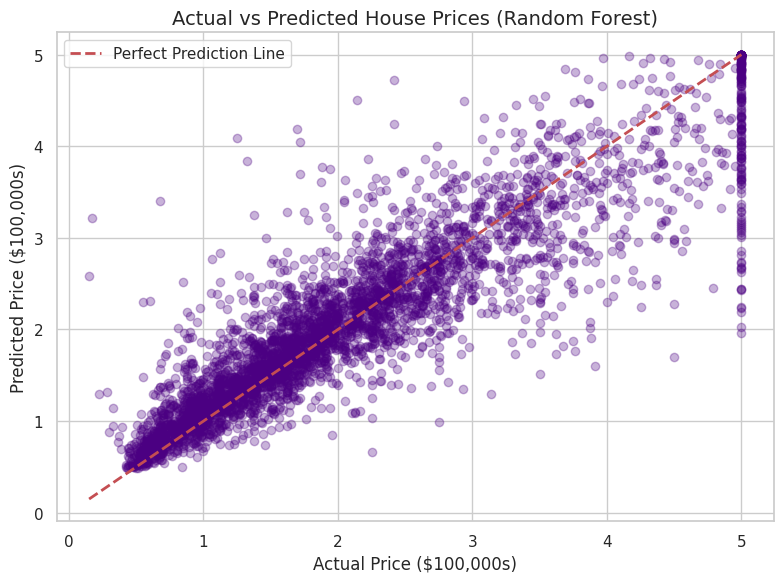


 7. FEATURE IMPORTANCE (RANDOM FOREST) 

--- Feature Importance Table ---
   Feature  Importance
    MedInc    0.524871
  AveOccup    0.138443
  Latitude    0.088936
 Longitude    0.088629
  HouseAge    0.054593
  AveRooms    0.044272
Population    0.030650
 AveBedrms    0.029606


/tmp/ipykernel_3264/3829351339.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='crest')


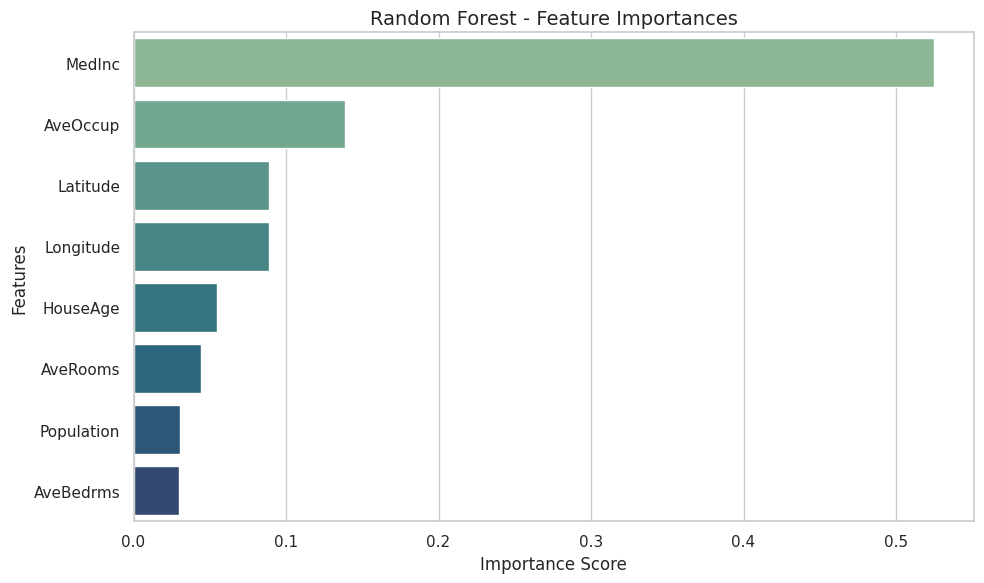


 8. SAMPLE PREDICTIONS (FIRST 10 TEST SAMPLES) 
 Actual Price ($100k)  Predicted Price ($100k)  Absolute Difference ($100k)
              0.47700                 0.509500                     0.032500
              0.45800                 0.741610                     0.283610
              5.00001                 4.923257                     0.076753
              2.18600                 2.529610                     0.343610
              2.78000                 2.273690                     0.506310
              1.58700                 1.646920                     0.059920
              1.98200                 2.376050                     0.394050
              1.57500                 1.669320                     0.094320
              3.40000                 2.772971                     0.627029
              4.46600                 4.913459                     0.447459

Project execution finished successfully.


In [ ]:
# ==============================================================================
# PROJECT TITLE: HOUSE PRICE PREDICTION USING MACHINE LEARNING
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ------------------------------------------------------------------------------
# 2. LOAD DATASET & DATA INSPECTION
# ------------------------------------------------------------------------------
print("="*80)
print(" 2. LOADING DATASET & INITIAL INSPECTION ")
print("="*80)

# Fetch California Housing Dataset as DataFrame
california = fetch_california_housing(as_frame=True)
df = california.frame

# Rename target column MedHouseVal to 'price' (Value is in $100,000s)
df = df.rename(columns={'MedHouseVal': 'price'})

print("\n--- First 5 Rows ---")
print(df.head())

print(f"\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Column Names ---")
print(list(df.columns))

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

# ------------------------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print(" 3. DATA CLEANING ")
print("="*80)

# Missing Values Check
missing_vals = df.isnull().sum()
print("\n--- Missing Values Count Per Column ---")
print(missing_vals)

if missing_vals.sum() == 0:
    print("-> Result: No missing values detected in the dataset.")
else:
    print("-> Result: Handling missing values by filling numerical features with median...")
    df.fillna(df.median(), inplace=True)

# Duplicate Rows Check
duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicate Rows Check ---")
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"-> Result: Removed {duplicate_count} duplicate rows. New shape: {df.shape}")
else:
    print("-> Result: No duplicate rows found.")

# ------------------------------------------------------------------------------
# 4. EXPLORATORY DATA ANALYSIS & CORRELATION
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print(" 4. EXPLORATORY DATA ANALYSIS (EDA) ")
print("="*80)

# Figure 1: Target Variable Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='skyblue', bins=50)
plt.title('Distribution of House Prices (in $100,000s)', fontsize=14)
plt.xlabel('Price ($100,000s)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# Figure 2: Feature Relationships with Target (Median Income & House Age vs Price)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Median Income vs Price
sns.scatterplot(ax=axes[0], data=df, x='MedInc', y='price', alpha=0.4, color='teal')
axes[0].set_title('Median Income vs House Price', fontsize=13)
axes[0].set_xlabel('Median Income ($10,000s)', fontsize=11)
axes[0].set_ylabel('Price ($100,000s)', fontsize=11)

# House Age vs Price
sns.scatterplot(ax=axes[1], data=df, x='HouseAge', y='price', alpha=0.3, color='coral')
axes[1].set_title('House Age vs House Price', fontsize=13)
axes[1].set_xlabel('House Age (Years)', fontsize=11)
axes[1].set_ylabel('Price ($100,000s)', fontsize=11)

plt.tight_layout()
plt.show()

# Figure 3: Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. FEATURE AND TARGET SELECTION
# ------------------------------------------------------------------------------
X = df.drop(columns=['price'])
y = df['price']

print(f"\nFeature Matrix (X) Shape: {X.shape}")
print(f"Target Vector (y) Shape: {y.shape}")

# ------------------------------------------------------------------------------
# 6. TRAIN-TEST SPLIT
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("\n--- Train-Test Split Results ---")
print(f"Training set size (X_train): {X_train.shape[0]} samples")
print(f"Testing set size (X_test):   {X_test.shape[0]} samples")

# ------------------------------------------------------------------------------
# 7. MODEL TRAINING & PREDICTION
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print(" 5. TRAINING MODELS ")
print("="*80)

# A. Linear Regression with Pipeline (Scaling applied directly inside Pipeline)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

print("\nTraining Linear Regression Model...")
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
print("Linear Regression Training Complete.")

# B. Random Forest Regressor (Tree models do not require scaling)
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest Regressor...")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Training Complete.")

# ------------------------------------------------------------------------------
# 8. MODEL EVALUATION
# ------------------------------------------------------------------------------
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

metrics_lr = evaluate_model(y_test, y_pred_lr, 'Linear Regression')
metrics_rf = evaluate_model(y_test, y_pred_rf, 'Random Forest')

# ------------------------------------------------------------------------------
# 9. MODEL COMPARISON
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print(" 6. MODEL EVALUATION & COMPARISON ")
print("="*80)

comparison_df = pd.DataFrame([metrics_lr, metrics_rf])
print("\n--- Model Performance Comparison ---")
print(comparison_df.to_string(index=False))

# ------------------------------------------------------------------------------
# 10. VISUAL MODEL COMPARISON
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison Bar Chart: R2 Score
sns.barplot(ax=axes[0], data=comparison_df, x='Model', y='R2 Score', palette='viridis')
axes[0].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=13)
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', fontsize=11, color='white', weight='bold')

# Comparison Bar Chart: MAE
sns.barplot(ax=axes[1], data=comparison_df, x='Model', y='MAE', palette='magma')
axes[1].set_title('Model Comparison: MAE (Lower is Better)', fontsize=13)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', fontsize=11, color='white', weight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 11. BEST MODEL SELECTION & ACTUAL VS PREDICTED
# ------------------------------------------------------------------------------
best_model_row = comparison_df.loc[comparison_df['R2 Score'].idxmax()]
best_model_name = best_model_row['Model']
best_r2 = best_model_row['R2 Score']

print("\n" + "="*80)
print(f" BEST PERFORMING MODEL: {best_model_name.upper()} ")
print(f" Best R² Score: {best_r2:.4f}")
print("="*80)

# Select best predictions for actual vs predicted plot
best_y_pred = y_pred_rf if best_model_name == 'Random Forest' else y_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_y_pred, alpha=0.3, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title(f'Actual vs Predicted House Prices ({best_model_name})', fontsize=14)
plt.xlabel('Actual Price ($100,000s)', fontsize=12)
plt.ylabel('Predicted Price ($100,000s)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 12. FEATURE IMPORTANCE (RANDOM FOREST)
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print(" 7. FEATURE IMPORTANCE (RANDOM FOREST) ")
print("="*80)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance Table ---")
print(feature_importances.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='crest')
plt.title('Random Forest - Feature Importances', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 13. SAMPLE PREDICTIONS
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print(" 8. SAMPLE PREDICTIONS (FIRST 10 TEST SAMPLES) ")
print("="*80)

sample_results = pd.DataFrame({
    'Actual Price ($100k)': y_test.iloc[:10].values,
    'Predicted Price ($100k)': best_y_pred[:10],
    'Absolute Difference ($100k)': np.abs(y_test.iloc[:10].values - best_y_pred[:10])
})

print(sample_results.to_string(index=False))
print("\nProject execution finished successfully.")